In [1]:
import sys
sys.path.insert(0, '..')

import os
import yaml
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from src.models.transfer_model import build_transfer_model
from src.utils.metrics import (
    get_predictions,
    show_confusion_matrix,
    show_classification_report
)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
train_dir = "../data/processed/train"
val_dir = "../data/processed/val"
test_dir = "../data/processed/test"

image_size = 224

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
val_data = datasets.ImageFolder(val_dir, transform=transform)
test_data = datasets.ImageFolder(test_dir, transform=transform)

num_classes = len(train_data.classes)
class_names = train_data.classes

print("Classes:", train_data.class_to_idx)
print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Classes: {'healthy': 0, 'low_tread': 1, 'sidewall_damaged': 2, 'uneven_wear': 3, 'zero_tread': 4}
Train: 520
Val: 60
Test: 67


In [4]:
batch_size = 16

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [5]:
model = build_transfer_model(
    model_name="mobilenet_v3_large",
    num_classes=num_classes,
    freeze_backbone=True
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:08<00:00, 2.61MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kern

In [6]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

In [7]:
epochs = 2

for epoch in range(epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    print(
        f"Epoch {epoch + 1} "
        f"Loss: {total_loss:.3f} "
        f"Accuracy: {train_acc:.3f}"
    )

Epoch 1 Loss: 42.130 Accuracy: 0.490
Epoch 2 Loss: 25.825 Accuracy: 0.773


In [8]:
model.eval()

val_correct = 0
val_total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

val_acc = val_correct / val_total

print("Validation accuracy:", val_acc)

Validation accuracy: 0.6


# 2. Hyperparameter Grid Search

In [9]:
learning_rates = [0.001, 0.0001]
batch_sizes = [16, 32]

search_epochs = 5

best_val_acc = 0.0
best_settings = None

search_results = []

for lr in learning_rates:
    for bs in batch_sizes:

        print("=" * 50)
        print("Trying learning rate:", lr)
        print("Trying batch size:", bs)

        train_loader_search = DataLoader(
            train_data,
            batch_size=bs,
            shuffle=True
        )

        val_loader_search = DataLoader(
            val_data,
            batch_size=bs,
            shuffle=False
        )

        # Fresh MobileNetV3-Large for every trial
        model_search = build_transfer_model(
            model_name="mobilenet_v3_large",
            num_classes=num_classes,
            freeze_backbone=True
        )

        model_search = model_search.to(device)

        loss_function = nn.CrossEntropyLoss()

        optimizer_search = optim.Adam(
            filter(lambda p: p.requires_grad, model_search.parameters()),
            lr=lr
        )

        # Training
        for epoch in range(search_epochs):

            model_search.train()

            for images, labels in train_loader_search:

                images = images.to(device)
                labels = labels.to(device)

                optimizer_search.zero_grad()

                outputs = model_search(images)

                loss = loss_function(outputs, labels)

                loss.backward()
                optimizer_search.step()

        # Validation
        model_search.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader_search:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model_search(images)

                predicted = outputs.argmax(dim=1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print("Validation accuracy:", round(val_acc, 4))

        search_results.append({
            "learning_rate": lr,
            "batch_size": bs,
            "val_accuracy": val_acc
        })

        # Keep the best combination
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_settings = {
                "learning_rate": lr,
                "batch_size": bs
            }

print("\n" + "=" * 50)
print("BEST SETTINGS")
print(best_settings)
print("BEST VALIDATION ACCURACY:", round(best_val_acc, 4))

Trying learning rate: 0.001
Trying batch size: 16
Validation accuracy: 0.4833
Trying learning rate: 0.001
Trying batch size: 32
Validation accuracy: 0.55
Trying learning rate: 0.0001
Trying batch size: 16
Validation accuracy: 0.55
Trying learning rate: 0.0001
Trying batch size: 32
Validation accuracy: 0.55

BEST SETTINGS
{'learning_rate': 0.001, 'batch_size': 32}
BEST VALIDATION ACCURACY: 0.55


In [10]:
final_config = {
    "model_name": "mobilenet_v3_large",
    "image_size": image_size,
    "batch_size": best_settings["batch_size"],
    "epochs": 20,
    "learning_rate": best_settings["learning_rate"],
    "freeze_backbone": True
}

os.makedirs("../configs", exist_ok=True)

with open("../configs/mobilenet_v3_large_config.yaml", "w") as f:
    yaml.dump(final_config, f)

print("Saved configuration:")
print(final_config)

Saved configuration:
{'model_name': 'mobilenet_v3_large', 'image_size': 224, 'batch_size': 32, 'epochs': 20, 'learning_rate': 0.001, 'freeze_backbone': True}


In [11]:
with open("../configs/mobilenet_v3_large_config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(config)

{'batch_size': 32, 'epochs': 20, 'freeze_backbone': True, 'image_size': 224, 'learning_rate': 0.001, 'model_name': 'mobilenet_v3_large'}


In [12]:
image_size = config["image_size"]
batch_size = config["batch_size"]
epochs = config["epochs"]
learning_rate = config["learning_rate"]
freeze_backbone = config["freeze_backbone"]

In [13]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(
    train_dir,
    transform=transform
)

val_data = datasets.ImageFolder(
    val_dir,
    transform=transform
)

test_data = datasets.ImageFolder(
    test_dir,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [14]:
model = build_transfer_model(
    model_name="mobilenet_v3_large",
    num_classes=num_classes,
    freeze_backbone=freeze_backbone
)

model = model.to(device)

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate
)

print("Final MobileNetV3-Large model is ready.")

Final MobileNetV3-Large model is ready.


In [15]:
os.makedirs("../results/mobilenet_v3_large", exist_ok=True)

best_model_path = "../results/mobilenet_v3_large/model.pt"

print("Results folder ready.")

Results folder ready.


# 3. Final Training

In [16]:
patience = 5

best_val_acc = 0.0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predicted = outputs.argmax(dim=1)

            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # =========================
    # SAVE BEST MODEL
    # =========================

    if val_acc > best_val_acc:

        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("  -> New best model saved.")

    else:

        epochs_without_improvement += 1

    # =========================
    # EARLY STOPPING
    # =========================

    if epochs_without_improvement >= patience:

        print(
            f"Early stopping triggered after "
            f"{patience} epochs without improvement."
        )

        break

print("\nBest validation accuracy:", best_val_acc)
print("Best model saved at:", best_model_path)

Epoch 1/20 | Loss: 1.3020 | Train Acc: 0.5000 | Val Acc: 0.5667
  -> New best model saved.
Epoch 2/20 | Loss: 0.8440 | Train Acc: 0.7365 | Val Acc: 0.6167
  -> New best model saved.
Epoch 3/20 | Loss: 0.6909 | Train Acc: 0.7865 | Val Acc: 0.6333
  -> New best model saved.
Epoch 4/20 | Loss: 0.5817 | Train Acc: 0.8385 | Val Acc: 0.6000
Epoch 5/20 | Loss: 0.5307 | Train Acc: 0.8673 | Val Acc: 0.5833
Epoch 6/20 | Loss: 0.4070 | Train Acc: 0.9154 | Val Acc: 0.5833
Epoch 7/20 | Loss: 0.3834 | Train Acc: 0.9115 | Val Acc: 0.5500
Epoch 8/20 | Loss: 0.3264 | Train Acc: 0.9327 | Val Acc: 0.5167
Early stopping triggered after 5 epochs without improvement.

Best validation accuracy: 0.6333333333333333
Best model saved at: ../results/mobilenet_v3_large/model.pt


In [17]:
model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)

print("Best MobileNetV3-Large weights loaded.")

Best MobileNetV3-Large weights loaded.


In [18]:
val_true, val_pred = get_predictions(
    model,
    val_loader,
    device
)

print("MOBILENETV3-LARGE VALIDATION RESULTS")

show_confusion_matrix(
    val_true,
    val_pred,
    class_names
)

show_classification_report(
    val_true,
    val_pred,
    class_names
)

MOBILENETV3-LARGE VALIDATION RESULTS
Confusion matrix
(rows = actual, columns = predicted)
Classes: ['healthy', 'low_tread', 'sidewall_damaged', 'uneven_wear', 'zero_tread']
[[17  0  2  1  2]
 [ 3  7  0  0  1]
 [ 1  0  7  0  0]
 [ 0  3  0  3  2]
 [ 2  2  3  0  4]]
                  precision    recall  f1-score   support

         healthy       0.74      0.77      0.76        22
       low_tread       0.58      0.64      0.61        11
sidewall_damaged       0.58      0.88      0.70         8
     uneven_wear       0.75      0.38      0.50         8
      zero_tread       0.44      0.36      0.40        11

        accuracy                           0.63        60
       macro avg       0.62      0.60      0.59        60
    weighted avg       0.64      0.63      0.62        60



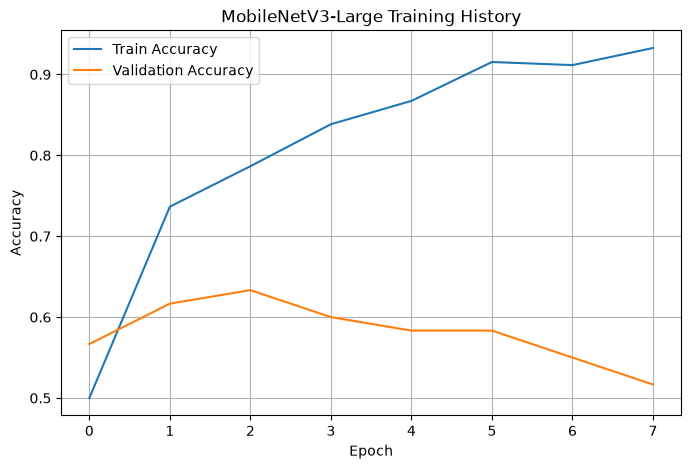

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3-Large Training History")
plt.legend()
plt.grid()

plt.savefig(
    "../results/mobilenet_v3_large/training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

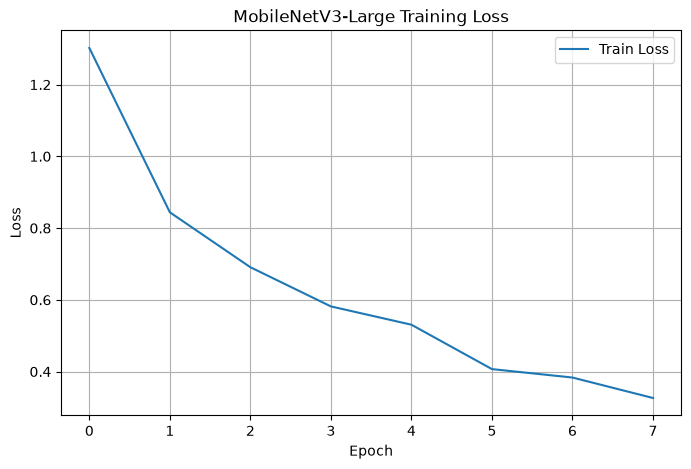

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"], label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3-Large Training Loss")
plt.legend()
plt.grid()

plt.savefig(
    "../results/mobilenet_v3_large/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
test_true, test_pred = get_predictions(
    model,
    test_loader,
    device
)

print("MOBILENETV3-LARGE FINAL TEST RESULTS")

show_confusion_matrix(
    test_true,
    test_pred,
    class_names
)

show_classification_report(
    test_true,
    test_pred,
    class_names
)

MOBILENETV3-LARGE FINAL TEST RESULTS
Confusion matrix
(rows = actual, columns = predicted)
Classes: ['healthy', 'low_tread', 'sidewall_damaged', 'uneven_wear', 'zero_tread']
[[16  4  3  0  0]
 [ 4  2  0  2  4]
 [ 2  0  7  0  0]
 [ 0  1  0  0  9]
 [ 1  2  1  1  8]]
                  precision    recall  f1-score   support

         healthy       0.70      0.70      0.70        23
       low_tread       0.22      0.17      0.19        12
sidewall_damaged       0.64      0.78      0.70         9
     uneven_wear       0.00      0.00      0.00        10
      zero_tread       0.38      0.62      0.47        13

        accuracy                           0.49        67
       macro avg       0.39      0.45      0.41        67
    weighted avg       0.44      0.49      0.46        67



In [22]:
from sklearn.metrics import classification_report

report_text = classification_report(
    test_true,
    test_pred,
    target_names=class_names
)

with open(
    "../results/mobilenet_v3_large/metrics.txt",
    "w"
) as f:

    f.write("Model: MobileNetV3-Large\n\n")

    f.write("Configuration:\n")
    f.write(str(config))
    f.write("\n\n")

    f.write("Best validation accuracy:\n")
    f.write(str(best_val_acc))
    f.write("\n\n")

    f.write("Final test results:\n")
    f.write(report_text)

print("Saved: results/mobilenet_v3_large/metrics.txt")

Saved: results/mobilenet_v3_large/metrics.txt
